# Entraînement du modèle

In [19]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

0.9736842105263158


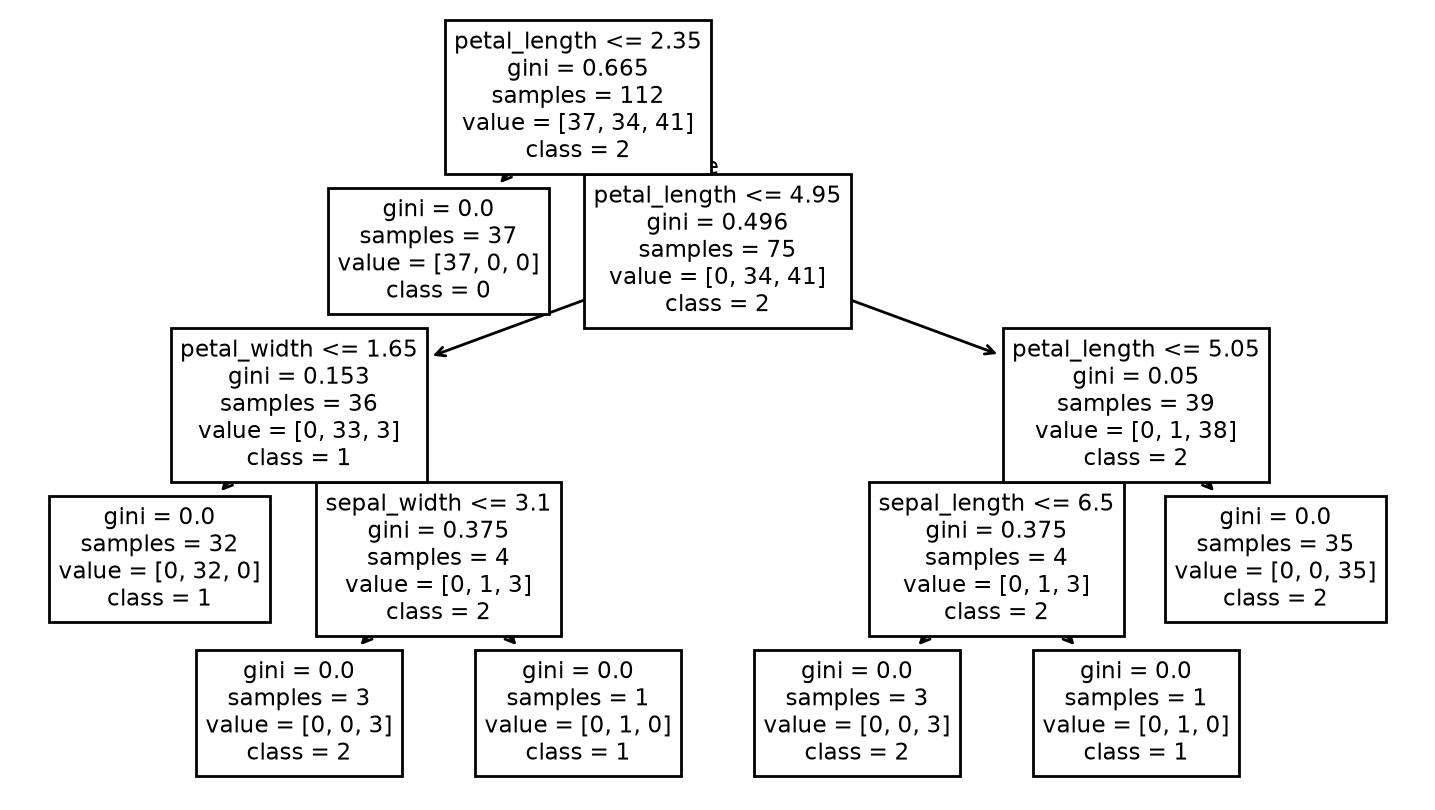

In [20]:
df = pd.read_csv("iris.csv")
df.head()

# 1. Séparer les features des targets

X = df.drop(axis="columns", columns=["target"])

y = df["target"]



# 1.A Ici nos targets sont déjà en numériques, dans le cas contraire :
"""

from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

y = LE.fit_transform(y)     => Vois quelle sont les différentes valeurs dans y et associe un nombre à chacune
"""

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.25, random_state = 0)

model = DecisionTreeClassifier() # Jouons d'abord sans paramètre

model.fit(X_train, y_train)  # Entrainer le modele

print(model.score(X_test,y_test))  # Test du modèle

figure = plt.figure(dpi=200, figsize=(9,5))
feat = X.columns
class_names = [str(c) for c in model.classes_]
plot_tree(model, feature_names=feat, class_names=class_names)
plt.show()



Par défaut, c'est le critère Gini (cas du DecisionTreeClassifier)

Avoir un Desicion Boundaries With Linear Discriminant Analysis
Nuage de point sepal lenght et sepal width

## Entrainement avec une regression logistique

Pour cet entrainement, je vais uniquement garder 2 features qui sont selon moi les plus pertinentes après mon EDA

0.9469026548672567


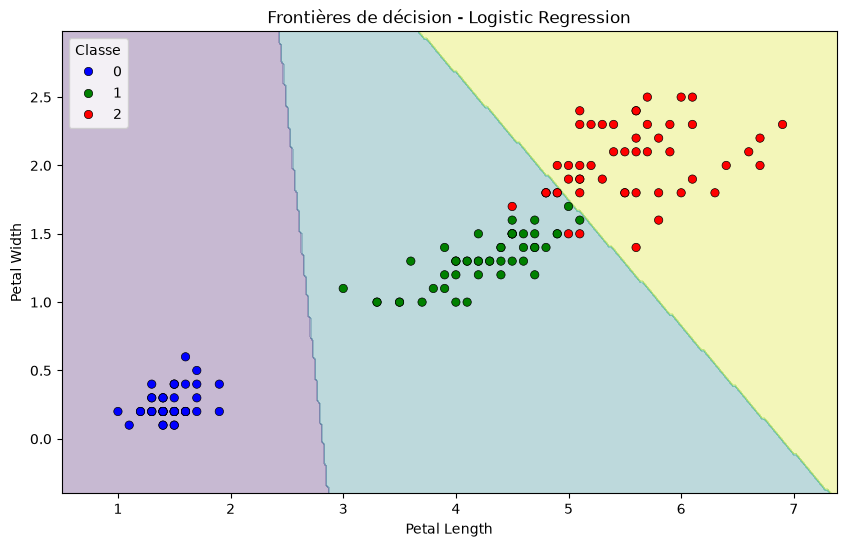

In [21]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder
 
# Load le dataset
data = pd.read_csv("iris.csv")
 
# Créer mon X contenant les features et y contenant la target

X = data[['petal_length','petal_width']]
y = data['target']

# Créer mon modele

model = LogisticRegression()

# Split mes datas
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.25,random_state=0)

# Entrainer mon modèle sur mes datas :

model.fit(X_train,y_train)

print(model.score(X_test,y_test))


# AFFICHAGE DES FRONTIERES DE DECISIONS

 # Création de la grille
x_min, x_max = X['petal_length'].min() - 0.5, X['petal_length'].max() + 0.5
y_min, y_max = X['petal_width'].min() - 0.5, X['petal_width'].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Prédiction sur toute la grille
Z = model.predict(
    pd.DataFrame({
        'petal_length': xx.ravel(),
        'petal_width': yy.ravel()
    })
)

# Conversion en matrice
Z = np.array(Z).reshape(xx.shape)

# Affichage des zones de décision
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Affichage des points du dataset
sns.scatterplot(
    data=data,
    x='petal_length',
    y='petal_width',
    hue='target',
    palette=['blue', 'green', 'red'],
    edgecolor='black'
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Frontières de décision - Logistic Regression')
plt.legend(title='Classe')
plt.show()

## Correction de l'entrainement en régression logique

In [22]:
logistic = LogisticRegression()

# Ici au lieu de garder longueur et largeur des pétales, on prends 1 data sur les pétales et 1 sur les sépales car les petal sont très correlées

X_log = data[['sepal_length','petal_length']]
y_log = data['target']

X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(X_log, y_log, test_size= 0.25, random_state=0)

logistic.fit(X_log_train, y_log_train)

logistic.score(X_log_test,y_log_test)

0.9473684210526315

<Axes: xlabel='sepal_length', ylabel='petal_length'>

<Figure size 640x480 with 0 Axes>

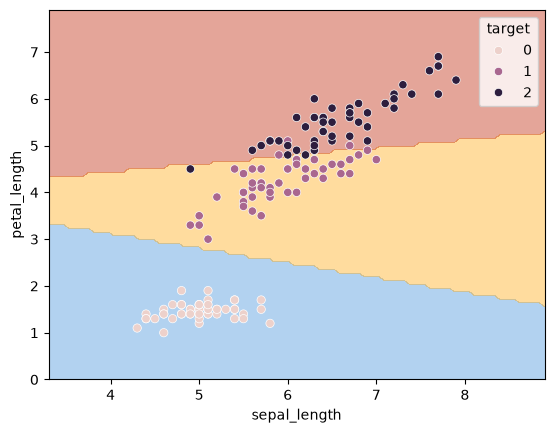

In [29]:
from sklearn.inspection import DecisionBoundaryDisplay
# Représenter les points
plt.figure()
DecisionBoundaryDisplay.from_estimator(logistic,
                                       X_log,
                                       response_method = 'predict',
                                       alpha = 0.4)
sns.scatterplot(x = X_log.to_numpy()[:,0],
                y = X_log.to_numpy()[:,1],
                hue=y_log)

# On pourrait faire la frontière de décision en récup les coeff directeur et les termes indépendants retournés par la régression logistique
# Cependant sklearn propose un méthode permettant de tracer la frontière décision


